In [1]:
import pandas as pd
from matplotlib import pyplot as plt
import numpy as np

import hmmlearn.hmm as hmm

import matplotlib.colors as mcolors
import matplotlib.dates as mdates

import lissa as li

import statsmodels.api as sm

from sklearn.preprocessing import power_transform


In [2]:
PCAData = pd.read_csv("../data/PCA/PCAtotal.csv",delimiter=",").fillna(0)
PCAData.rename(columns={"Unnamed: 0":"time"},inplace=True)

PCAHeaders = [str(i) for i in range(0,8)]

pumpList = PCAData["Well Run"].unique()


/tmp/ipykernel_97176/452915461.py:1: DtypeWarning: Columns (14,15) have mixed types. Specify dtype option on import or set low_memory=False.
  PCAData = pd.read_csv("../data/PCA/PCAtotal.csv",delimiter=",").fillna(0)


In [3]:
PCAData[["Transformed Radius","VibNormX","VibNormY"]] = 0.0

for pump in pumpList:
    pumpData = PCAData.loc[PCAData["Well Run"] == pump]
    PCAData.loc[pumpData.index,"Transformed Radius"] = li.BoxCoxProccess(pumpData,"Radius")
    PCAData.loc[pumpData.index,"VibNormX"] = li.BoxCoxProccess(pumpData,"ESP Vibration X")
    PCAData.loc[pumpData.index,"VibNormY"] = li.BoxCoxProccess(pumpData,"ESP Vibration Y")

modelData = PCAData.loc[PCAData["Well_down"]==0].copy() #dados de operação apenas, dados desligados não são considerados


In [4]:
# transformedData = pd.DataFrame(columns=list(PCAData),index=range(len(PCAData)))
# notOpHeader = list(set(list(PCAData))-set(PCAHeaders))

# transformedData[notOpHeader] = PCAData[notOpHeader]


# for pump in pumpList:
#     data = PCAData.loc[PCAData["Well Run"]==pump]
#     newData = PowerTransformer().fit_transform(data[PCAHeaders])
#     transformedData.loc[PCAData["Well Run"]==pump,PCAHeaders] = newData.copy()

In [5]:
# fig, ax = li.QQPlots(PCAData,"PCAHeaders")
# fig.suptitle("Componentes da PCA")

# PCAData["Radius"].hist(bins=20)
# plt.title("Histograma do Raio")


# PCAData["Transformed Radius"].hist(bins=20)
# plt.title("Histograma do Transformação do Raio")

# sm.qqplot(PCAData["Transformed Radius"], line='s')


In [6]:
#PCAData["Transformed Radius"].hist(bins=20)
#PCAData["Radius"].hist()

In [7]:
mainSeed = 19971215

np.random.seed(mainSeed)
proportion = 0.75
modelData = modelData.sort_values(["Well Run","time"])
X_train,trainLength, X_test, testLength = li.Splitter(pumpList,proportion,modelData)

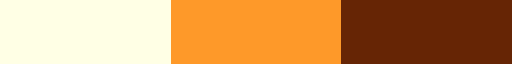

In [8]:
# Exemplo de estados ao longo do tempo
n = 2
states = range(0,n+1)

# Gerando cores automáticas com base no número de estados
num_states = len(np.unique(states))
cmap = plt.get_cmap('YlOrBr', num_states)  # Escolhe um colormap com num_states cores

cmap

In [9]:
totalLength = np.concatenate([trainLength,testLength])

modelData = pd.concat([X_train,X_test])

In [10]:
model = hmm.GMMHMM(n_components=n,n_mix=2,covariance_type="full",random_state=mainSeed)
#model = hmm.GaussianHMM(n_components=n,random_state=mainSeed)
model.fit(X_train[PCAHeaders],trainLength)#+['Water Cut @ 20degC - 1 atm','Choke Opening']])
modelData["State"] = model.predict(modelData[PCAHeaders],totalLength)+1;

np.log(model.aic(X_train[PCAHeaders]))

PCAData["State"] = 0
PCAData.loc[modelData["State"].index,"State"] = modelData["State"]

In [11]:
#li.QQPlots(PCAData[["ESP Vibration Y","ESP Vibration X"]],["ESP Vibration Y","ESP Vibration X"])

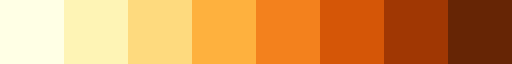

In [12]:
# Exemplo de estados ao longo do tempo
n_1 = 7
states_1 = range(0,n_1+1)
# Gerando cores automáticas com base no número de estados
cmap1 = plt.get_cmap('YlOrBr', n_1+1)  # Escolhe um colormap com num_states cores

cmap1

In [13]:
modelSq = hmm.GaussianHMM(n_components=n_1,random_state=mainSeed)
modelSq.fit(X_train["Transformed Radius"].to_numpy().reshape(-1,1),trainLength)#+['Water Cut @ 20degC - 1 atm','Choke Opening']])
modelData["State 2"] = modelSq.predict(modelData["Transformed Radius"].to_numpy().reshape(-1,1),totalLength)+1;

np.log(modelSq.aic(X_train["Transformed Radius"].to_numpy().reshape(-1,1)))

PCAData["State Gaussian"] = 0
PCAData.loc[modelData["State 2"].index,"State Gaussian"] = modelData["State 2"]


In [14]:
modelVib = hmm.GaussianHMM(n_components=n_1,random_state=mainSeed)
modelVib.fit(X_train[["VibNormX","VibNormY"]],trainLength)#+['Water Cut @ 20degC - 1 atm','Choke Opening']])
modelData["State Vib"] = modelSq.predict(modelData[["VibNormX","VibNormY"]],totalLength)+1;

np.log(modelVib.aic(X_train[["VibNormX","VibNormY"]]))

PCAData["State Vib"] = 0
PCAData.loc[modelData["State Vib"].index,"State Vib"] = modelData["State Vib"]

In [15]:
print(model.get_stationary_distribution())
print(modelSq.get_stationary_distribution())
print(modelVib.get_stationary_distribution())

[0.50323193 0.49676807]
[0.12525413 0.012841   0.21259911 0.17682692 0.10837522 0.25814344
 0.10596019]
[0.09347531 0.02510271 0.26892337 0.25778795 0.17862303 0.00157869
 0.17450894]


In [16]:
stateOrder = np.argsort(modelSq.get_stationary_distribution())+1
stateOrder = np.insert(np.flip(stateOrder),0,0)

conversion = dict(zip(stateOrder,range(0,n_1+1)))
PCAData["State Gaussian"] = PCAData["State Gaussian"].map(conversion)

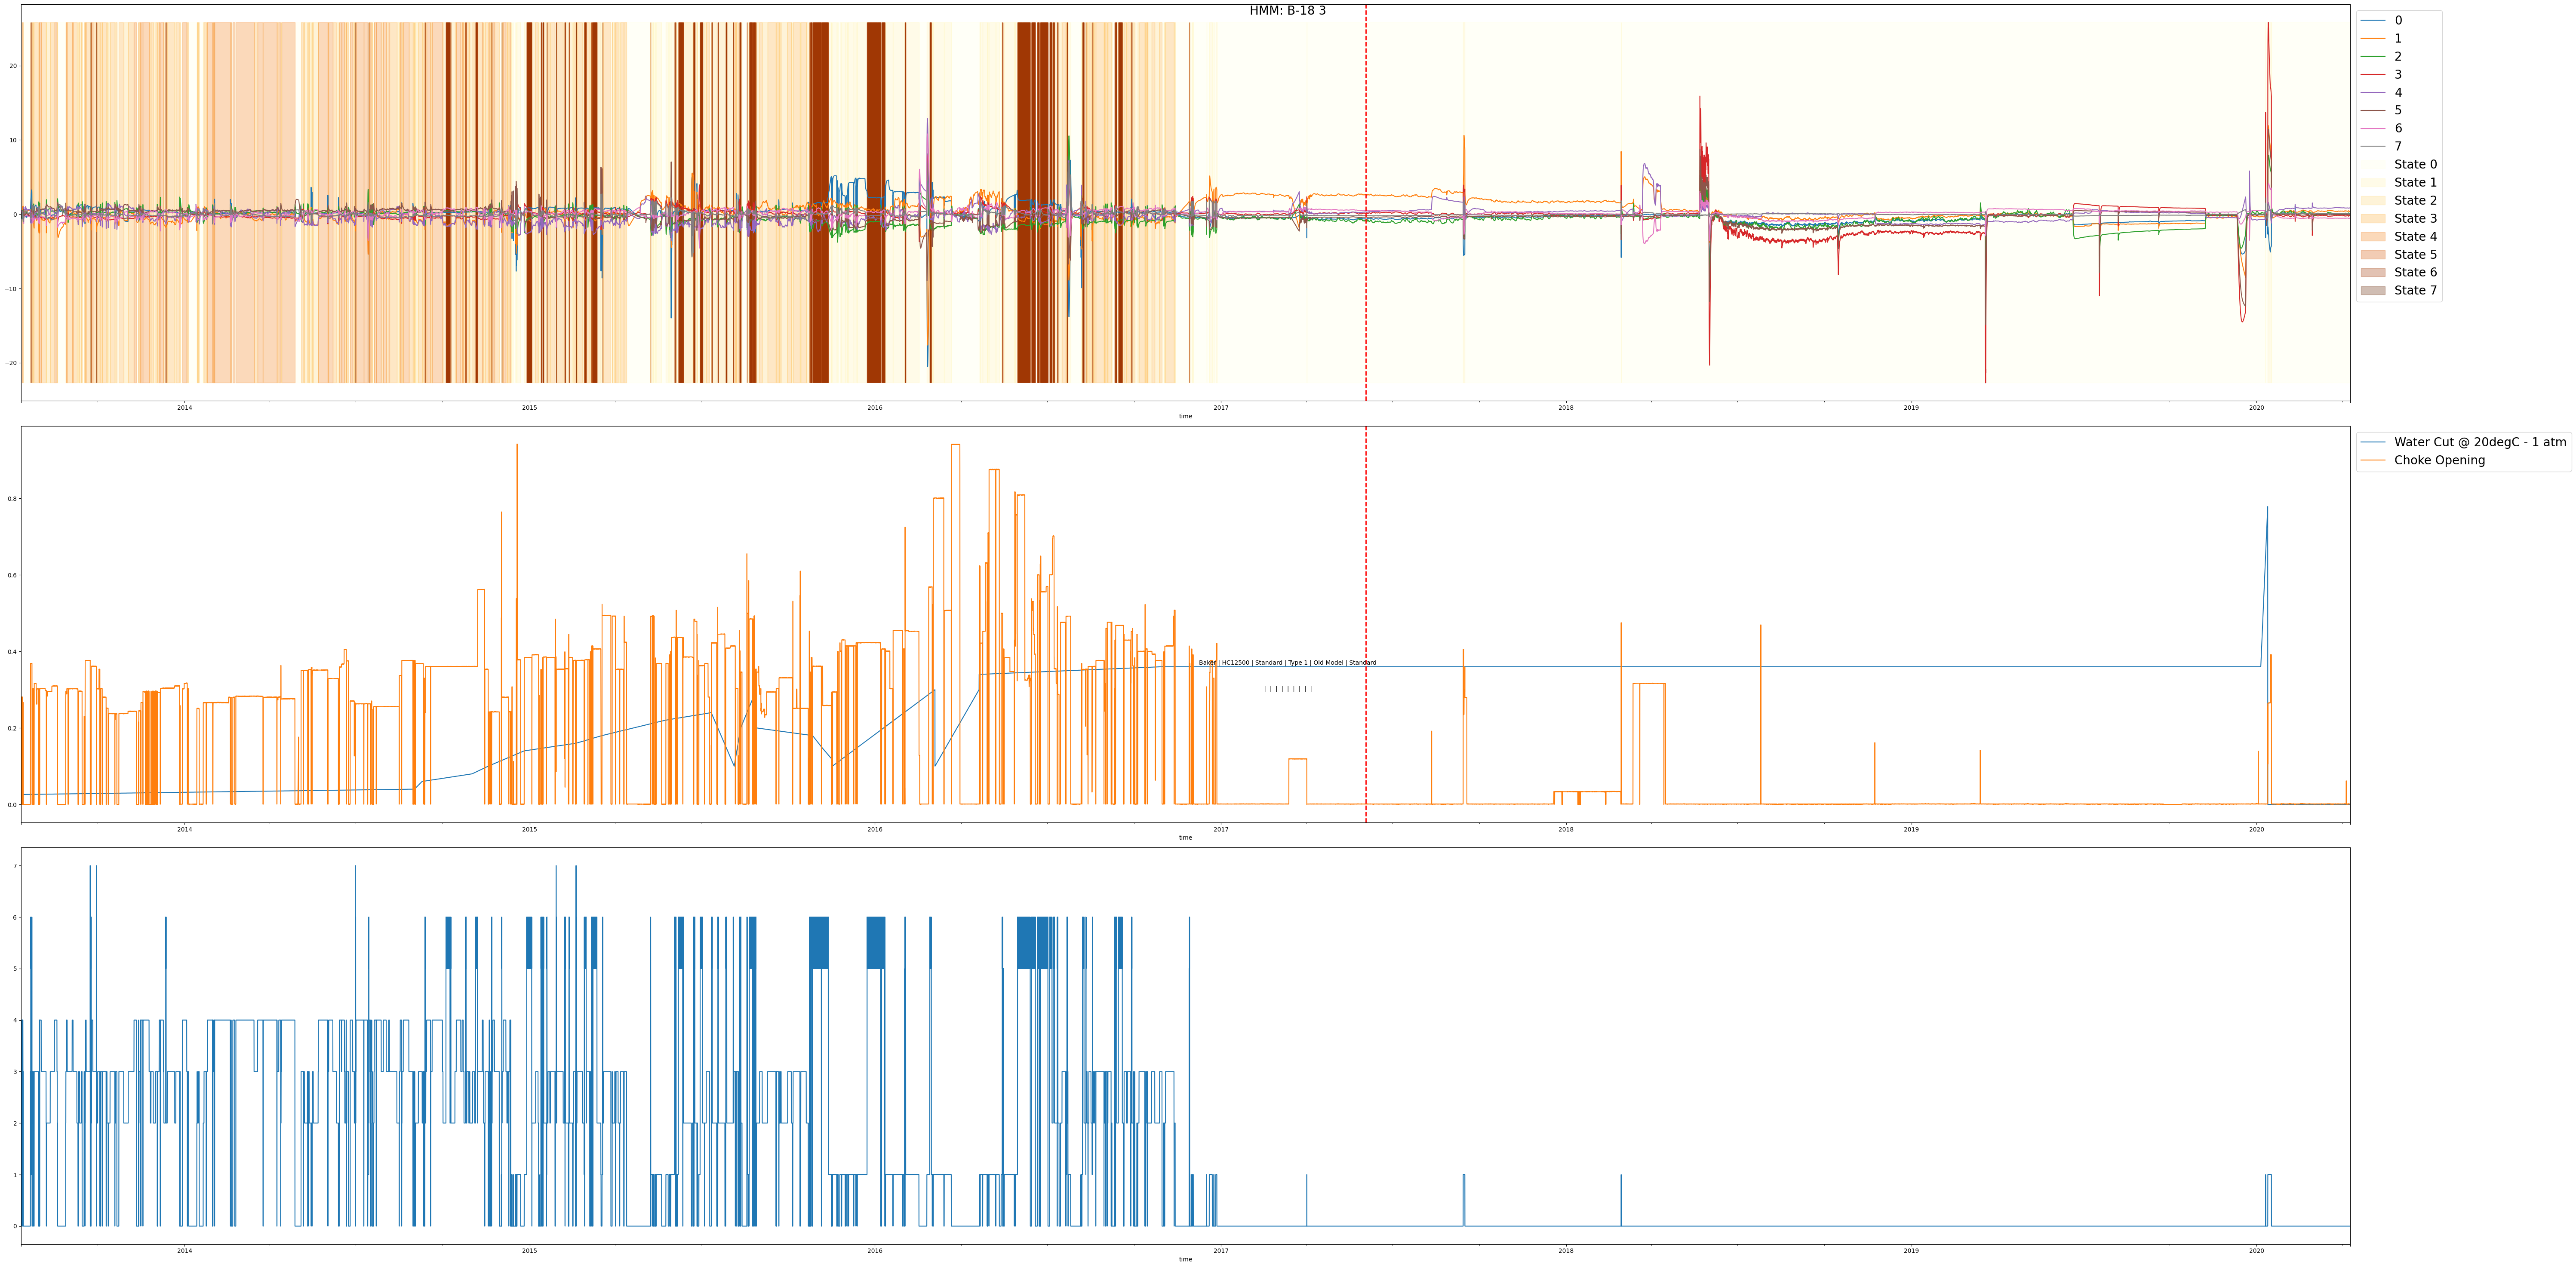

In [17]:
pump = pumpList[3]
pumpData = PCAData.loc[PCAData["Well Run"]==pump].copy()
fig,axs = li.HMMPicture(pumpData,pump,PCAHeaders,cmap1,n_1)
fig.savefig("teste")


In [18]:
# for pump in pumpList:
   
#     pumpData = PCAData.loc[PCAData["Well Run"]==pump].copy()

#     fig, axs = li.HMMPicture(pumpData,pump,PCAHeaders,cmap1,n_1)

#     fig.savefig("imagens/heatmap2/heatmap-"+pump+".png")
#     plt.close()

In [19]:
# import dynamax.hidden_markov_model as hmm


# model = hmm.LinearAutoregressiveHMM(num_states=4,emission_dim=5)
# model.fit_em()


#  pumpData = PCAData.loc[PCAData["Well Run"]==pump].copy()

#     pumpData["time"] = pd.to_datetime(pumpData["time"])
#     pumpData.set_index("time",inplace=True)

#     pumpData = pumpData.asfreq('h',fill_value=0)

#     pumpData["Shutdown"] = pumpData["Well_down"] != pumpData["Well_down"].shift(-1).fillna(pumpData["Well_down"].iloc[-1])

#     fig, ax = plt.subplots(4,1, figsize=(50,15))

#     pumpData[PCAHeaders].plot(ax=ax[0])


#     # Preenchendo as áreas de acordo com os estados
#     for state in np.unique(states):
#         color = cmap(state)  # Pega uma cor automática para cada estado
#         ax[0].fill_between(pumpData.index, np.min(pumpData[PCAHeaders]), np.max(pumpData[PCAHeaders]), where=(pumpData["State"] == state), 
#                         color=color, alpha=0.3, label=f"Estado {state}")
        
#     ax[0].legend(loc='upper left',bbox_to_anchor=(1, 1))


#     # for shut in pumpData["Shutdown"].loc[pumpData["Shutdown"] == True].index:
#     #       ax[0].axvline(x=shut, color='black', linestyle='-', linewidth=0.5)





#     norm = mcolors.Normalize(vmin=-6, vmax=6)

#     its = ax[3].pcolor(pumpData[PCAHeaders].T,cmap='hsv', norm=norm)
#     ax[3].grid(axis="y",linewidth=1,color="black")
#     ax[3].tick_params(axis='both', which='both', length=0)  # Remove ticks
#     ax[3].set_xticklabels([])  # Remove labels no eixo x


#     ax[3].set_title(str(pumpData["Pump Info"].iloc[0])+" "+str(pumpData["Failure Info"].iloc[0]))




#     if pumpData.loc[pumpData["Failure"]==True].shape[0] != 0:
#             failureX = pumpData.index.get_loc(pumpData.loc[pumpData["Failure"]==True].index[0])
#             ax[3].axvline(x=failureX, color='red', linestyle='--', linewidth=1)


#     fig.colorbar(its,ax=ax[3],orientation='horizontal',shrink=0.5)


#     fig.suptitle("HMM e Imshow: " + pump);
#     plt.tight_layout()
#     fig.savefig("imagens/heatmap2/heatmap-"+pump+".png")
#     plt.close()

In [20]:
# pump = pumpList[0]
# pumpData = PCAData.loc[PCAData["Well Run"]==pump].copy()
# plt.rcParams['font.size'] = 15.0
# pumpData["time"] = pd.to_datetime(pumpData["time"])
# pumpData.set_index("time",inplace=True)

# pumpData = pumpData.asfreq('h',fill_value=0)

# pumpData["Shutdown"] = pumpData["Well_down"] != pumpData["Well_down"].shift(-1).fillna(pumpData["Well_down"].iloc[-1])


# fig, ax = plt.subplots(1,1, figsize=(20,10))

# pumpData[PCAHeaders].plot(ax=ax)


# # Preenchendo as áreas de a
# # cordo com os estados
# for state in np.unique(states):
#         color = cmap(state)  # Pega uma cor automática para cada estado
#         ax.fill_between(pumpData.index, np.min(pumpData[PCAHeaders]), np.max(pumpData[PCAHeaders]), where=(pumpData["State"] == state), 
#                         color=color, alpha=0.3, label=f"State {state}")

#         ax.legend(loc='upper left',bbox_to_anchor=(1, 1),fontsize=15)



# if pumpData.loc[pumpData["Failure"]==True].shape[0] != 0:
#         #failureX = pumpData.index.get_loc(pumpData.loc[pumpData["Failure"]==True].index[0])
#         ax.axvline(x=pumpData.loc[pumpData["Failure"]==True].index[0], color='red', linestyle='--', linewidth=5)


# fig.suptitle("HMM: " + pump,fontsize=20);
# fig.savefig("imagens/relatorio/hmm")